# вариант 4

Дополнительный вариант.

Рассматриваемый ряд: средняя цена номера, chicago metropolitan area.

Решение выполняется аналогично предыдущему варианту. Ниже приведены расчёты и результаты для данного показателя.


In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from IPython.display import display

# делаем графики чуть аккуратнее
plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.2f}'.format


In [2]:
# задаем параметры текущего варианта
variant_number = 4
column = 'x4'
series_title = 'средняя цена номера, chicago metropolitan area'
series_unit = '$'

month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12,
}

month_names_ru = {
    1: 'январь',
    2: 'февраль',
    3: 'март',
    4: 'апрель',
    5: 'май',
    6: 'июнь',
    7: 'июль',
    8: 'август',
    9: 'сентябрь',
    10: 'октябрь',
    11: 'ноябрь',
    12: 'декабрь',
}


## загружаем и подготавливаем данные

In [3]:
data = pd.read_csv('data.csv', sep=';', dtype=str)

data['month'] = data['date1'].map(month_map)
data['date'] = pd.to_datetime(
    dict(year=data['date2'].astype(int), month=data['month'], day=1)
)

data[column] = pd.to_numeric(
    data[column].str.replace(',', '.', regex=False),
    errors='coerce'
)

series = data.set_index('date')[column]
train = series.dropna()
future_dates = series[series.isna()].index

print(f'вариант: {variant_number}')
print(f'столбец: {column}')
print(f'известных наблюдений: {len(train)}')
print(f'месяцев для прогноза: {len(future_dates)}')

display(data[['date', column]].head())
display(data[['date', column]].tail(12))


вариант: 4
столбец: x4
известных наблюдений: 112
месяцев для прогноза: 8


,date,x4
0,1994-01-01,72.15
1,1994-02-01,73.47
2,1994-03-01,74.91
3,1994-04-01,79.06
4,1994-05-01,82.07


,date,x4
108,2003-01-01,92.88
109,2003-02-01,90.99
110,2003-03-01,99.62
111,2003-04-01,101.32
112,2003-05-01,NaN
113,2003-06-01,NaN
114,2003-07-01,NaN
115,2003-08-01,NaN
116,2003-09-01,NaN
117,2003-10-01,NaN


## смотрим на исходный временной ряд

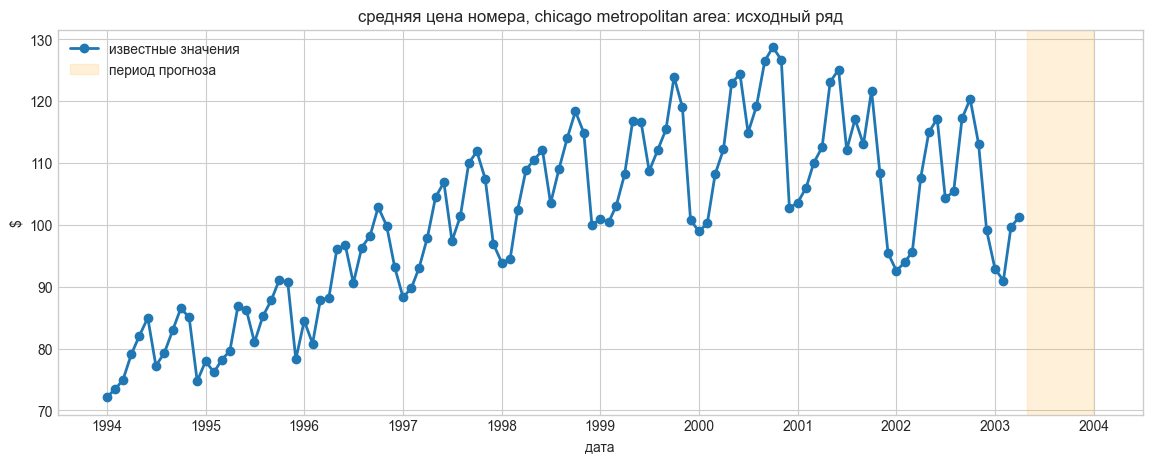

In [4]:
# строим график известных значений
plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, marker='o', linewidth=2, label='известные значения')

# подсвечиваем участок, который будем прогнозировать
if len(future_dates) > 0:
    plt.axvspan(
        future_dates[0],
        future_dates[-1] + pd.offsets.MonthEnd(1),
        color='orange',
        alpha=0.15,
        label='период прогноза'
    )

plt.title(f'{series_title}: исходный ряд')
plt.xlabel('дата')
plt.ylabel(series_unit)
plt.legend()
plt.show()


## делаем сезонную декомпозицию

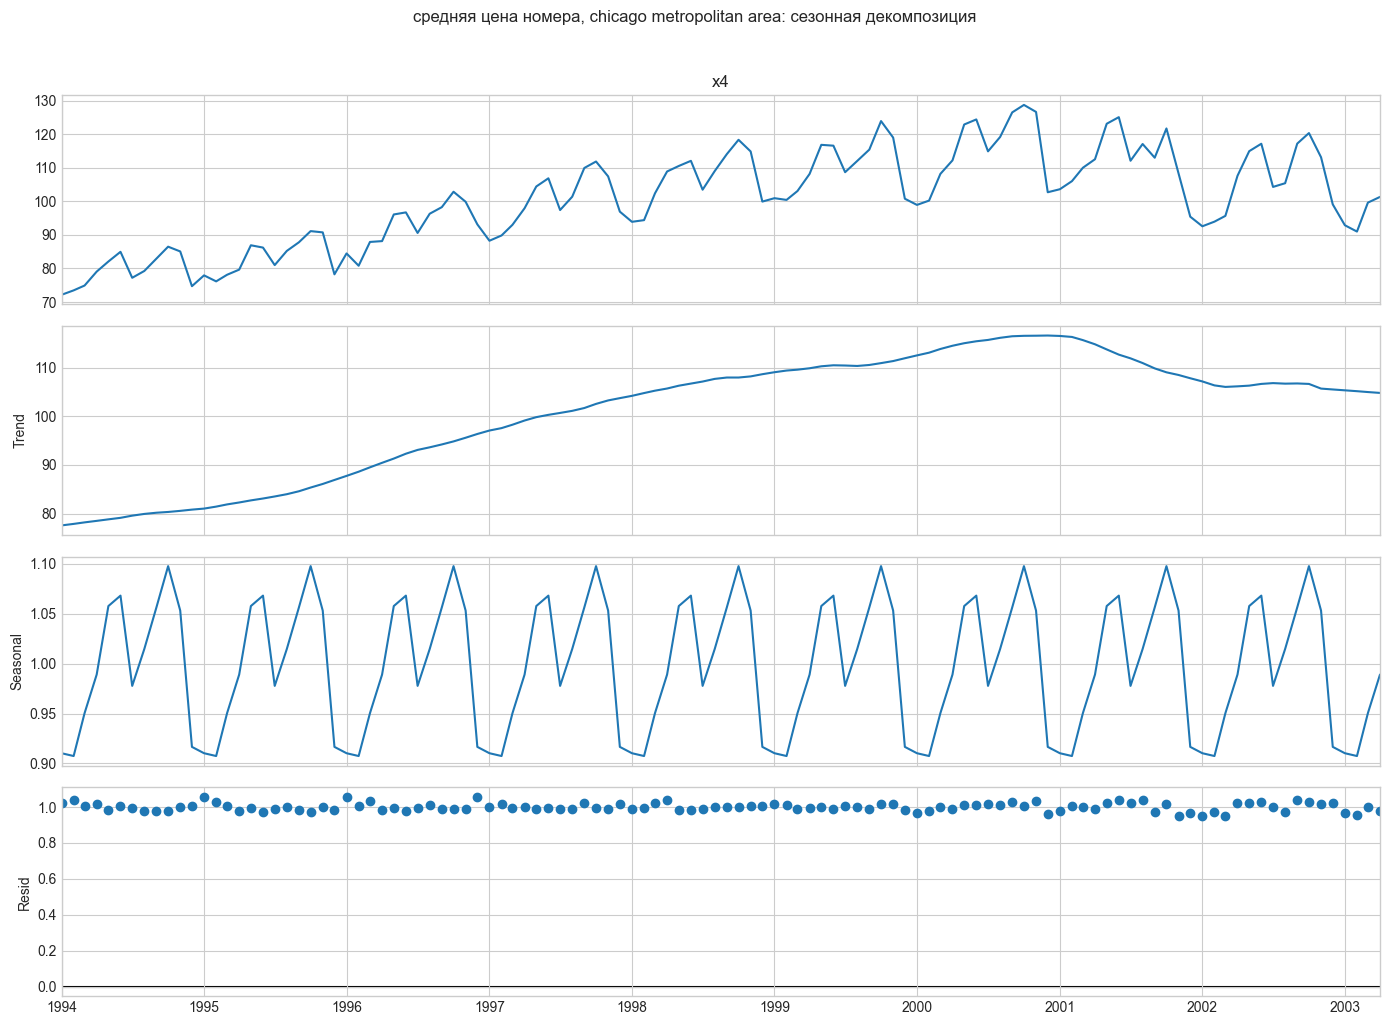

In [5]:
# раскладываем ряд на компоненты

decomposition = seasonal_decompose(
    train,
    model='multiplicative',
    period=12,
    extrapolate_trend='freq'
)

# показываем графики компонентов
fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle(f'{series_title}: сезонная декомпозиция', y=1.02)
plt.tight_layout()
plt.show()


## выписываем сезонные коэффициенты

In [6]:
# усредняем сезонные коэффициенты по каждому месяцу
seasonal_pattern = decomposition.seasonal.groupby(decomposition.seasonal.index.month).mean()

# оформляем таблицу в удобном виде
seasonal_table = pd.DataFrame({
    'месяц': [month_names_ru[m] for m in seasonal_pattern.index],
    'сезонный коэффициент': seasonal_pattern.values
})

display(seasonal_table)


,месяц,сезонный коэффициент
0,январь,0.91
1,февраль,0.91
2,март,0.95
3,апрель,0.99
4,май,1.06
5,июнь,1.07
6,июль,0.98
7,август,1.01
8,сентябрь,1.06
9,октябрь,1.10


## убираем сезонность и строим тренд

уравнение тренда: y = 83.465 + 0.314 * t


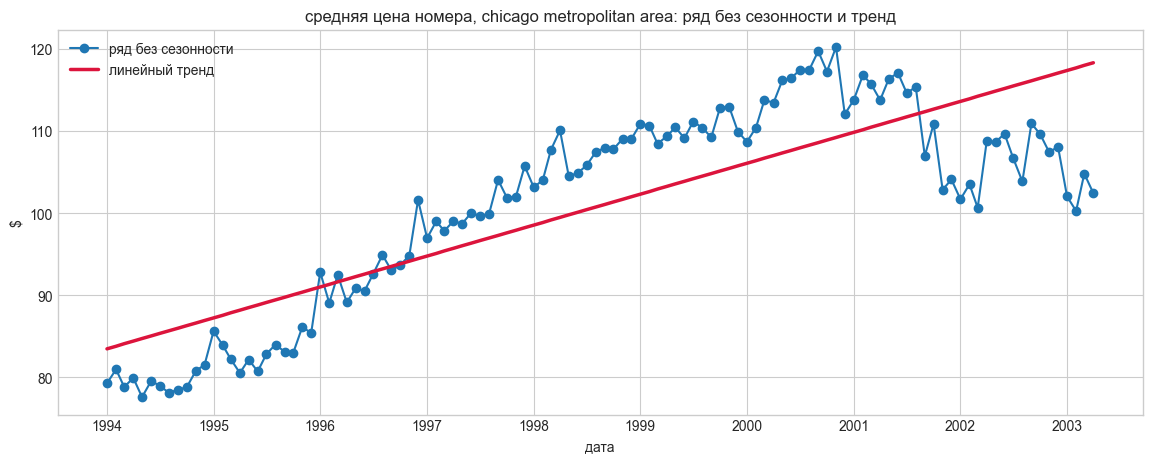

In [7]:
# убираем сезонность

deseasonalized = train / decomposition.seasonal

# кодируем время числами 0, 1, 2, ...
time_index = np.arange(len(deseasonalized))

# строим линейный тренд по формуле прямой
slope, intercept = np.polyfit(time_index, deseasonalized.values, 1)
trend_line = intercept + slope * time_index

print(f'уравнение тренда: y = {intercept:.3f} + {slope:.3f} * t')

# показываем ряд без сезонности и тренд
plt.figure(figsize=(14, 5))
plt.plot(train.index, deseasonalized.values, marker='o', label='ряд без сезонности')
plt.plot(train.index, trend_line, color='crimson', linewidth=2.5, label='линейный тренд')
plt.title(f'{series_title}: ряд без сезонности и тренд')
plt.xlabel('дата')
plt.ylabel(series_unit)
plt.legend()
plt.show()


## строим прогноз на 8 месяцев

In [8]:
# продолжаем тренд на будущие месяцы
future_time_index = np.arange(len(deseasonalized), len(deseasonalized) + len(future_dates))
future_trend = intercept + slope * future_time_index

# подбираем сезонные коэффициенты для будущих месяцев
future_season = np.array([seasonal_pattern[date.month] for date in future_dates])

# получаем итоговый прогноз
forecast = future_trend * future_season

# собираем красивую таблицу прогноза
forecast_table = pd.DataFrame({
    'дата': [f"{month_names_ru[date.month]} {date.year}" for date in future_dates],
    f'прогноз, {series_unit}': np.round(forecast, 2)
})

display(forecast_table)


,дата,"прогноз, $"
0,май 2003,125.51
1,июнь 2003,127.09
2,июль 2003,116.63
3,август 2003,121.36
4,сентябрь 2003,126.68
5,октябрь 2003,131.98
6,ноябрь 2003,126.96
7,декабрь 2003,110.77


## смотрим итоговый график

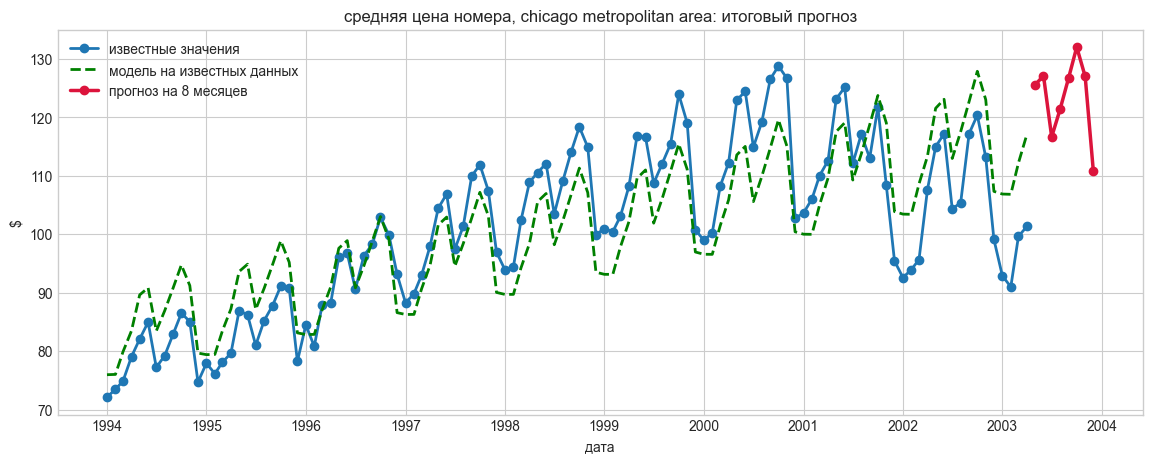

In [9]:
# восстанавливаем модель на известной части ряда
fitted = trend_line * np.array([seasonal_pattern[date.month] for date in train.index])

# строим итоговый график
plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, marker='o', linewidth=2, label='известные значения')
plt.plot(train.index, fitted, linestyle='--', linewidth=2, color='green', label='модель на известных данных')
plt.plot(future_dates, forecast, marker='o', linewidth=2.5, color='crimson', label='прогноз на 8 месяцев')
plt.title(f'{series_title}: итоговый прогноз')
plt.xlabel('дата')
plt.ylabel(series_unit)
plt.legend()
plt.show()


## собираем итоговую таблицу

In [10]:
# подставляем прогноз вместо пропусков
result = data[['date', column]].copy()
result['итоговое значение'] = result[column]
result.loc[result['итоговое значение'].isna(), 'итоговое значение'] = forecast

# добавляем удобную подпись месяца
result['месяц'] = result['date'].apply(lambda d: f"{month_names_ru[d.month]} {d.year}")

# показываем последние 12 месяцев ряда
final_table = result[['месяц', 'итоговое значение']].tail(12).reset_index(drop=True)
display(final_table)


,месяц,итоговое значение
0,январь 2003,92.88
1,февраль 2003,90.99
2,март 2003,99.62
3,апрель 2003,101.32
4,май 2003,125.51
5,июнь 2003,127.09
6,июль 2003,116.63
7,август 2003,121.36
8,сентябрь 2003,126.68
9,октябрь 2003,131.98


## вывод

Расчёты выполнены аналогично предыдущему варианту. Получен прогноз на 8 месяцев для показателя средней цены номера.
